In [1]:
from autocvd import autocvd
autocvd(num_gpus = 1, interval=1)

from functools import partial

# timing and progress bars
from timeit import default_timer as timer
from tqdm import tqdm
import pickle

# numerics
import jax
import jax.numpy as jnp
import optimistix as optx
import equinox as eqx
import flax
import optax

from jax import jit

from flow_CrossAttentionSetTransformer import Flow
from dataloader import OdisseoOTAllParametersPosition_newprior


In [2]:
dataloader_train = OdisseoOTAllParametersPosition_newprior(
            DATA_ROOT = '/export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior',
            num_samples= 100_000,
            split= [0, 94999],
            seed= 0,
            num_steps = 2000,
            batch_size = 32,
            use_jax = False)

SEED = 5678
dim_flow = 13
N_dim = 64
N_head = 2
depth = 2
key = jax.random.PRNGKey(SEED)
key, subkey = jax.random.split(key, 2)
flow = Flow(dim_flow=dim_flow,
            N_dim=N_dim,
            N_head=N_head, 
            depth=depth, 
            sample_size=1000,
            ln=False,)

flow_params = flow.init_weights(subkey)

import orbax
# Load Orbax checkpoint
checkpoint_dir = '/export/home/vgiusepp/sbi_diff_sim/sbi-sim/flow_matching_personal/checkpoint_0'

try:
    # Create Orbax checkpointer
    checkpointer = orbax.checkpoint.PyTreeCheckpointer()
    
    # Restore checkpoint with target structure
    best_params = checkpointer.restore(checkpoint_dir, item=flow_params)
    
    # Verify parameters were loaded
    param_count = sum(x.size for x in jax.tree_util.tree_leaves(best_params))
    print(f"Successfully loaded {param_count} parameters from Orbax checkpoint")
    
except Exception as e:
    print(f"Failed to load Orbax checkpoint: {e}")
    print("Using fresh parameters")
    best_params = flow_params


key = jax.random.PRNGKey(0)
t = jnp.linspace(0, 1, 1).reshape(-1, 1)
theta = jax.random.normal(key, (1, 13))
x_obs = jax.random.normal(key, (1, 1000, 6))
flow.apply({'params': best_params}, timesteps=t, sample=theta, encoder_hidden_states=x_obs)

odisseo_AllParametersPosition_newprior
DATA_ROOT: /export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior/
Loading odisseo_AllParametersPosition_newprior locally from existing directory /export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior
using numpy to load
using numpy to load
Dataloader sampling without replacements (num_steps: 2969)
Failed to load Orbax checkpoint: module 'orbax' has no attribute 'checkpoint'
Using fresh parameters


Array([[ 0.00324005,  0.00058035,  0.00494389, -0.00387668,  0.0009761 ,
         0.00196257, -0.00274646, -0.00316672, -0.00379536, -0.00314533,
         0.00182089, -0.00034084, -0.0044716 ]], dtype=float32)

In [4]:
from sampler import ODESolver
num_samples = 300
key, rng = jax.random.split(key)
solver = ODESolver()
dictionary_sampling, _ = solver.sample(num_samples=num_samples, dim=dim_flow, model=flow, params={'params': best_params}, rng=rng, conditioning=x_obs.repeat(num_samples, axis=0), z_init=None )
samples = dictionary_sampling['samples']


In [19]:
dictionary_sampling['trajectory'].shape

(10, 300, 13)

using numpy to load
using numpy to load
using numpy to load


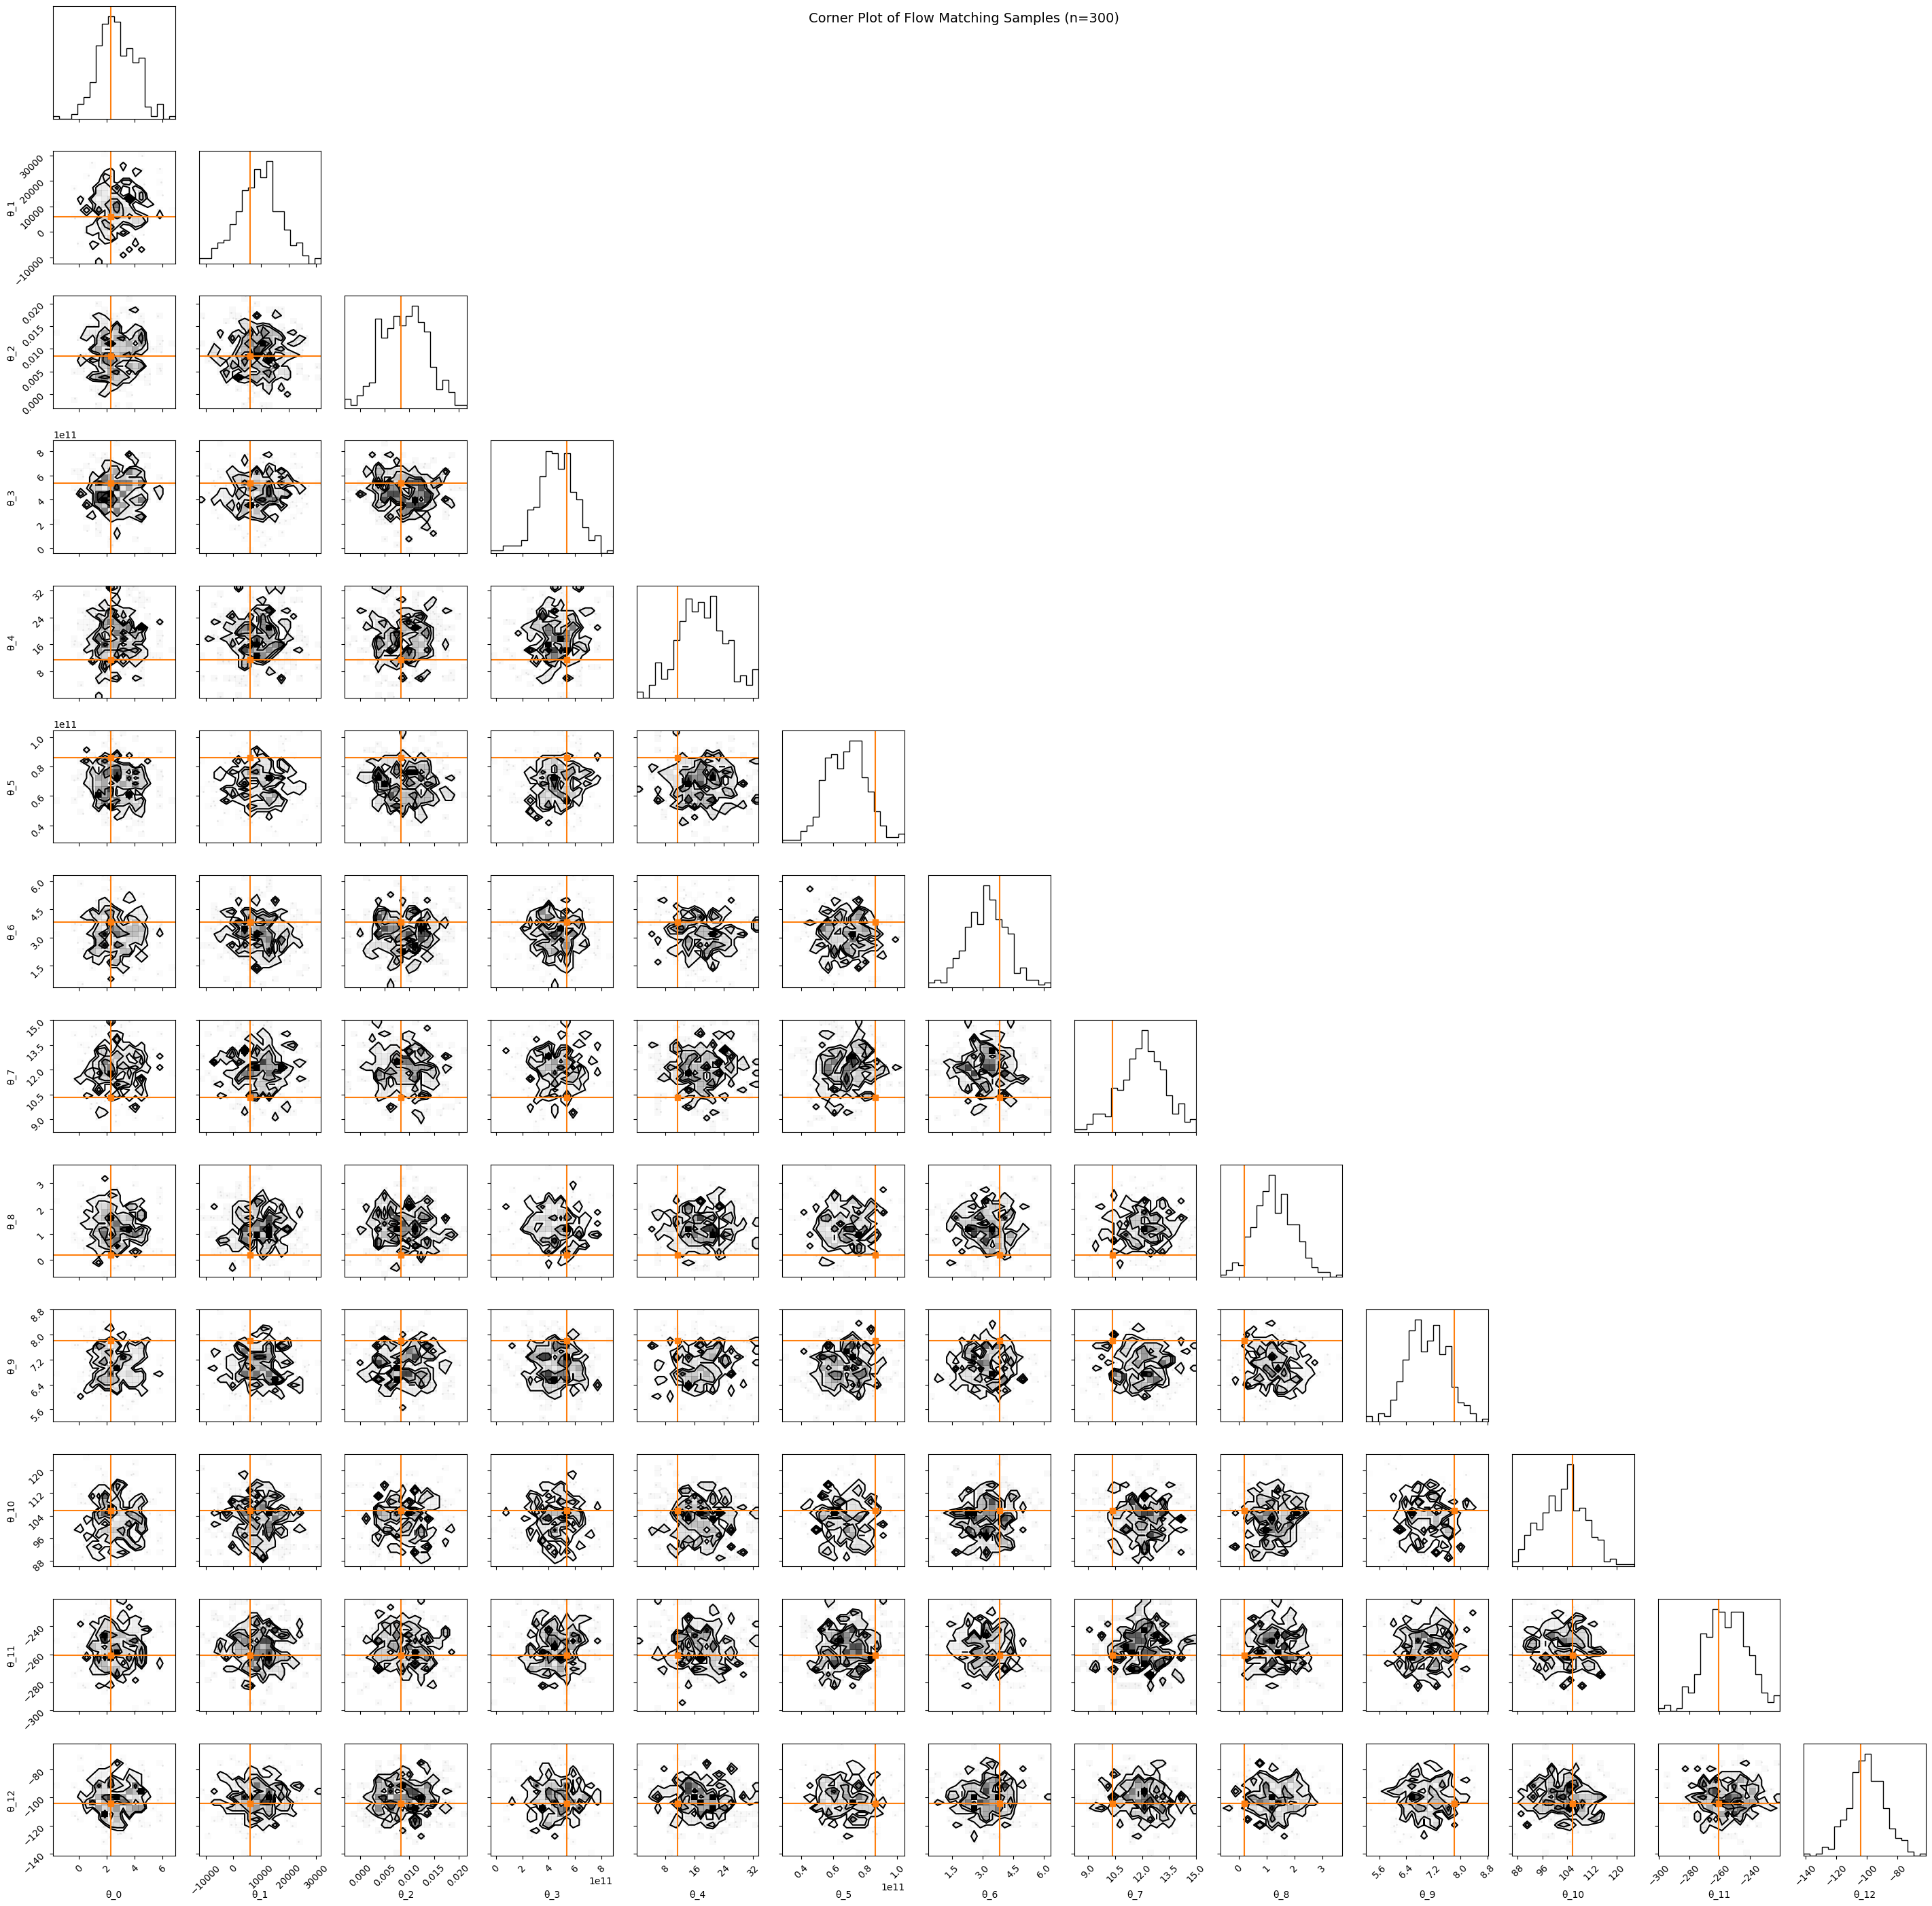

using numpy to load
using numpy to load
using numpy to load


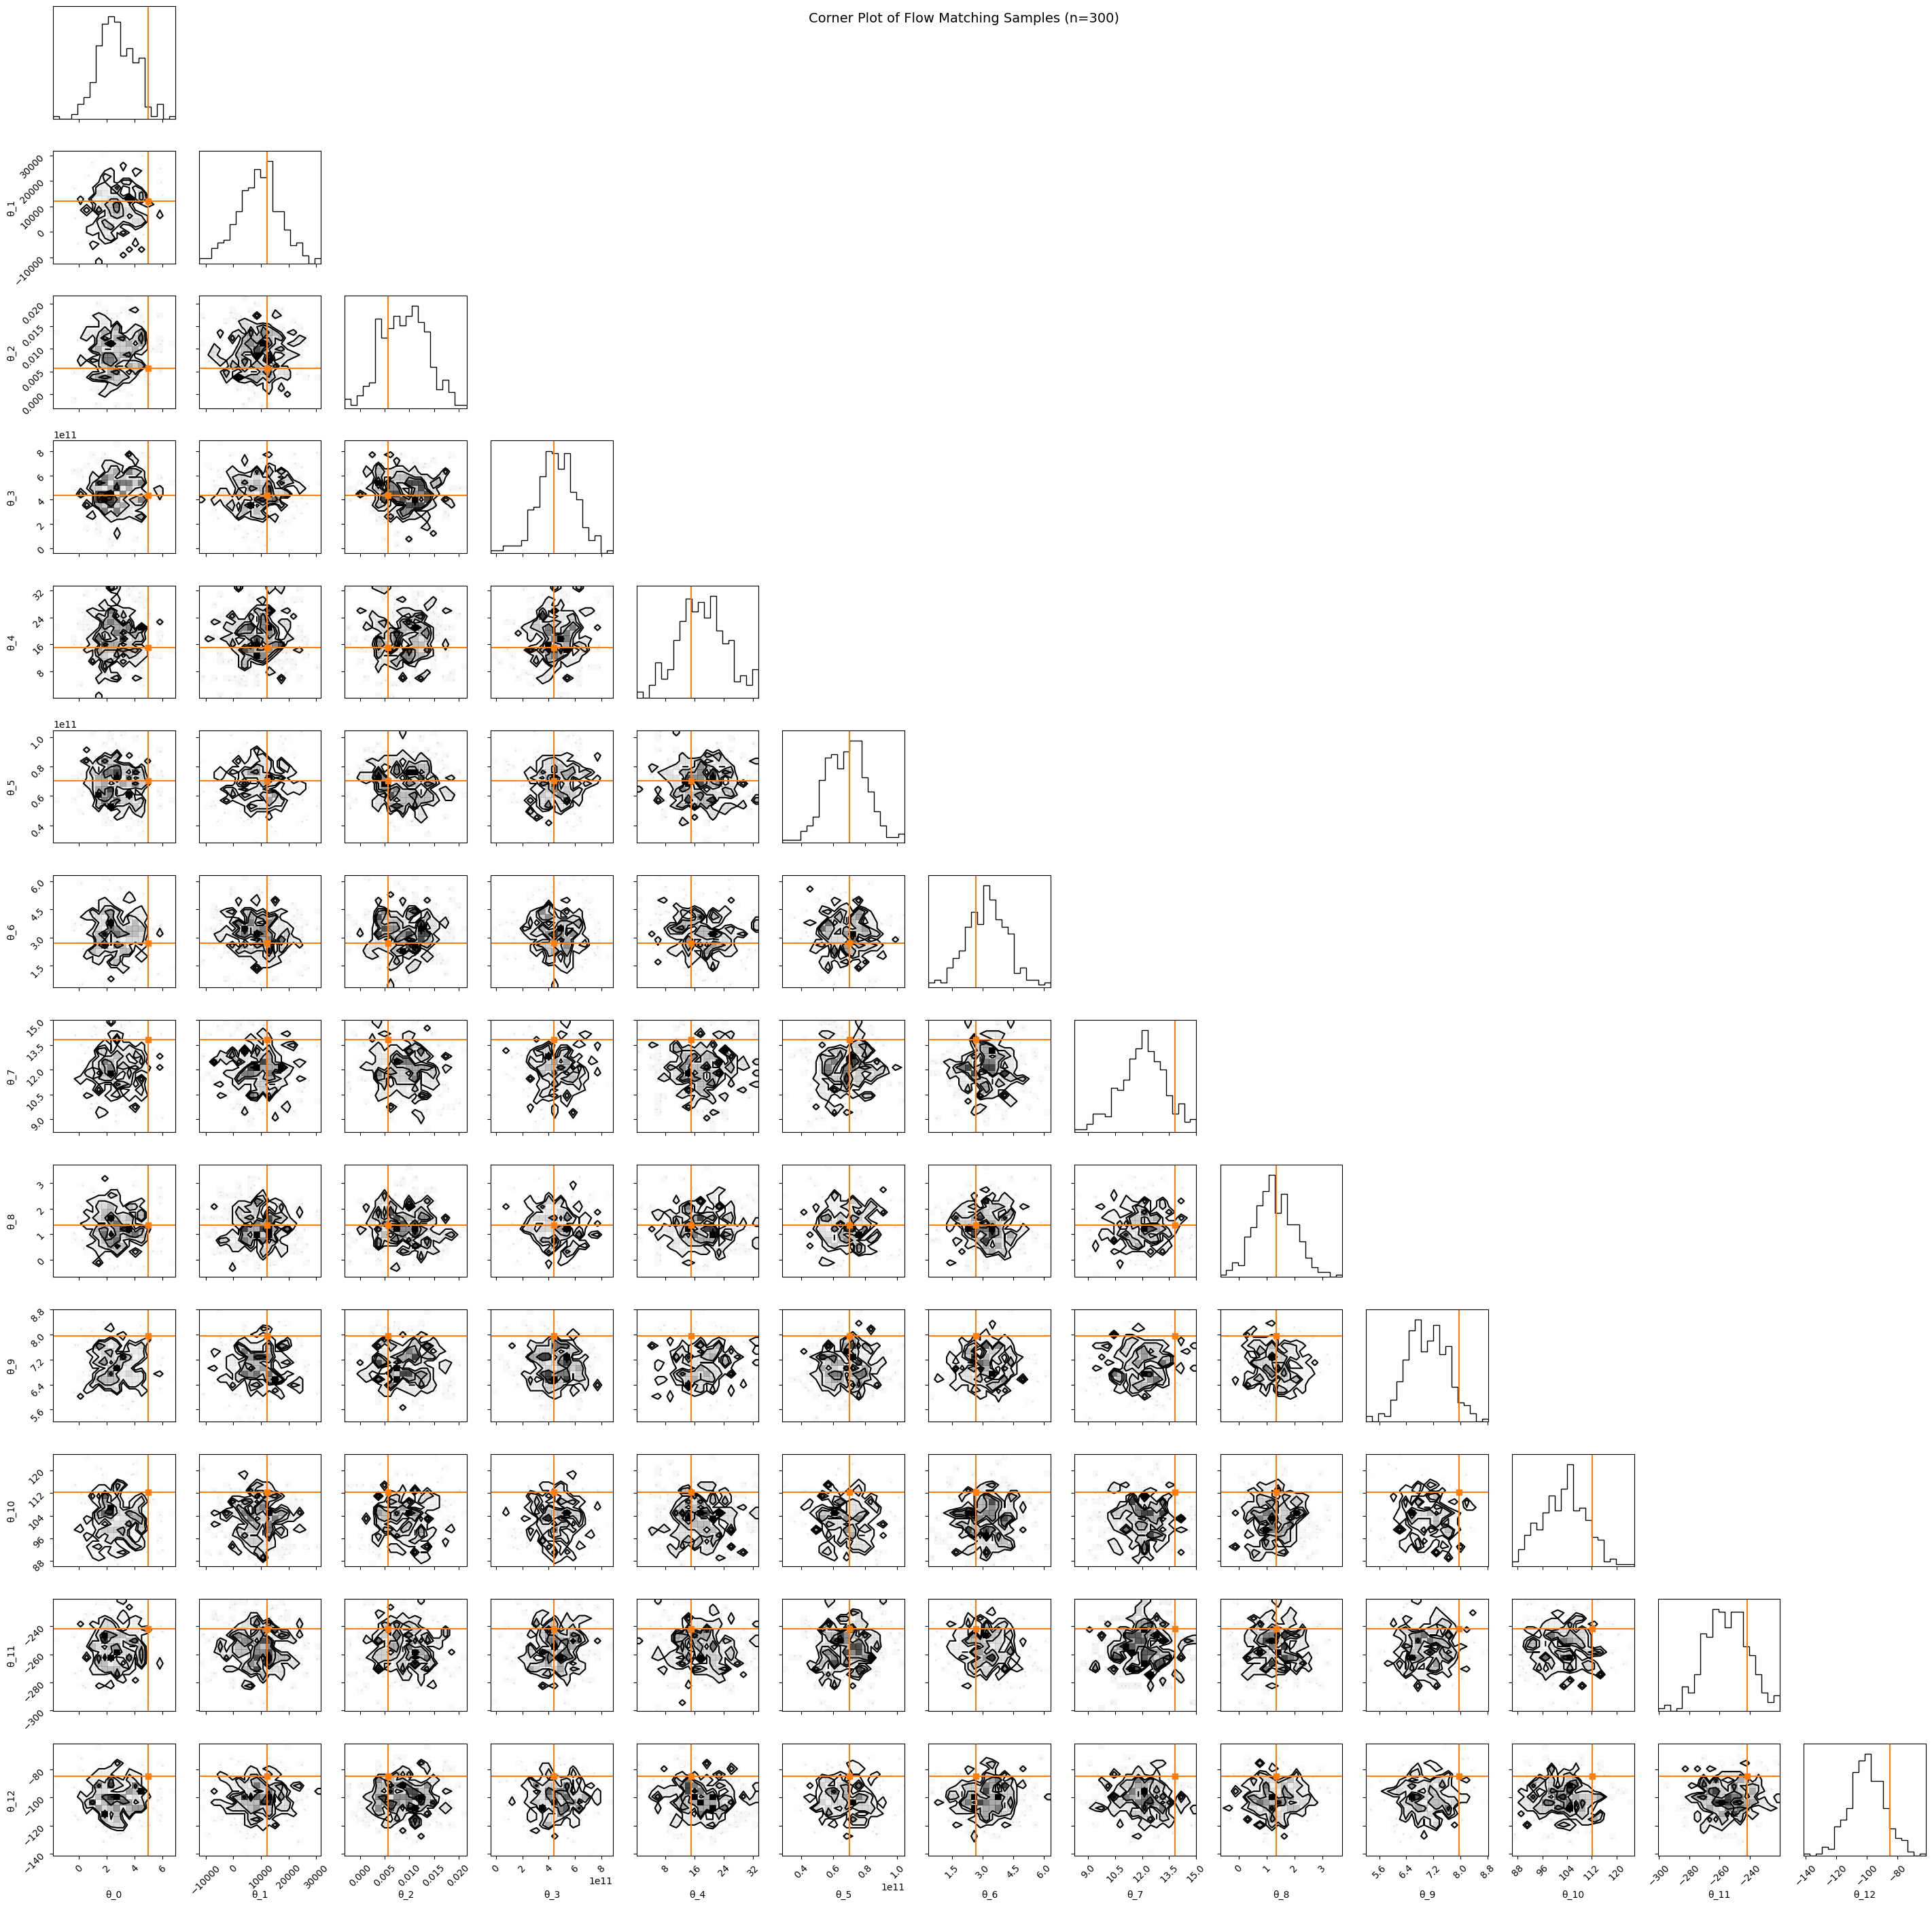

In [16]:
for id in [1, 2]:
    observation, true_theta, reference_posterior = dataloader_train.get_observation(id)
    dictionary_sampling, _ = solver.sample(num_samples=num_samples, dim=dim_flow, model=flow, params={'params': best_params}, rng=rng, conditioning=observation.repeat(num_samples, axis=0), z_init=None )
    samples = dictionary_sampling['samples']

    samples = np.array(samples)
    samples = samples * dataloader_train.std_X + dataloader_train.mean_X  # Unnormalize samples
    # Create corner plot
    fig = corner.corner(
        samples, 
        labels=[f'θ_{i}' for i in range(dim_flow)],  # Parameter labels θ_0, θ_1, ..., θ_12
    )
    corner.overplot_lines(fig, true_theta[0], color="C1")
    corner.overplot_points(fig, true_theta, marker="s", color="C1")

    plt.suptitle(f'Corner Plot of Flow Matching Samples (n={num_samples})', fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show();